# Le topic modeling avec BERTopic

Une approche de ML, non surpervisée, permettant d'extraire les thématiques/topics présents dans un ensemble de données textuelles.

**Ressources :**  
- le très bon tuto de Axel Morin : https://css-polytechnique.github.io/css-ipp-materials/pages/bertopic-tutorial.html
- le site de BERTopic : https://maartengr.github.io/BERTopic/index.html
  

In [ ]:
%pip install bertopic
#%pip install -q bertopic pandas sentence-transformers scikit-learn stopwordsiso umap-learn hdbscan plotly

In [1]:
import pandas as pd
from bertopic import BERTopic

df = pd.read_csv("https://raw.githubusercontent.com/pyshs/URFIST-Lyon-2026/refs/heads/main/data/css_openalex_26022026.csv")
df["title"] = df["title"].fillna("")
df["abstract"] = df["abstract"].fillna("")
df["texte"] = df["title"]+ df["abstract"]
df = df[(df["texte"].str.len() > 100) & (df["texte"].str.len() < 5000)]
df.head(3)

docs = df["texte"].tolist()

# # Ou charger des données avec pandas depuis une URL
# data_url = "https://raw.githubusercontent.com/pyshs/URFIST-Lyon-2026/refs/heads/main/data/css_openalex_26022026.csv"
# df_url = pd.read_csv(data_url)
# docs = df_url["abstract"].tolist()

## Le TM à la hache

### Créer un pipeline et entraîner le modèle

In [3]:
# Le minimum du minimum sans rien affiner :
# (mais en fait plein de choix par défauts qui sont "cachés")
topic_model = BERTopic()
topics, probs = topic_model.fit_transform(docs)

In [6]:
df["cluster"] = topics

In [17]:
#topic_model.get_document_info(docs)

### Et explorer les résultats :

In [ ]:
# # Les principales fonctions à tester pour avoir un aperçu simple :

# topic_model.get_topic_info()[0:10]
# topic_model.visualize_barchart())
# topic_model.visualize_topics() # Meeh https://github.com/MaartenGr/BERTopic/issues/2269#issuecomment-2607040736
# topic_model.visualize_hierarchy()
# topic_model.visualize_heatmap()
# topic_model.get_document_info(docs)
# topic_model.visualize_documents(docs)


## Mais c'est plus compliqué

En réalité, on a une série de briques de traitements, et une série de choix par défauts sont réalisés (et l'on peut aller modifier ces briques) :
- 1 Embeddings
- 2 Dimensionality Reduction
- 3 Clustering
- 4 Tokenizer/vectorizer
- 5 Weighting Scheme
- 6 Representation Tuning

Donc un mille (bon six…) feuilles
![](https://maartengr.github.io/BERTopic/algorithm/default.svg)

Et plein de choix possibles :
![](https://maartengr.github.io/BERTopic/algorithm/modularity.svg)


### On peut donc modifier les étapes

In [18]:
from umap import UMAP
from hdbscan import HDBSCAN
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from bertopic.vectorizers import ClassTfidfTransformer


# Step 1 - Extract embeddings
# all-MiniLM-L6-v2 | paraphrase-multilingual-MiniLM-L12-v2 | all-mpnet-base-v2
embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

# Step 2 - Reduce dimensionality
umap_model = UMAP(
    n_neighbors=15,  # 15 par défaut
    n_components=5,  # 2 par défaut
    min_dist=0.2,  # 0.1 par défaut
    metric="cosine",  # "euclidean" par défaut
)

# Step 3 - Cluster reduced embeddings
hdbscan_model = HDBSCAN(
    # min_cluster_size=5,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True,
)

# Step 4 - Tokenize topics
vectorizer_model = CountVectorizer(stop_words="english")

# Step 5 - Create topic representation
ctfidf_model = ClassTfidfTransformer()

# Step 6 - (Optional) Fine-tune topic representations with
# a `bertopic.representation` model
representation_model = KeyBERTInspired()

# All steps together
topic_model = BERTopic(
    embedding_model=embedding_model,  # Step 1 - Extract embeddings
    umap_model=umap_model,  # Step 2 - Reduce dimensionality
    hdbscan_model=hdbscan_model,  # Step 3 - Cluster reduced embeddings
    vectorizer_model=vectorizer_model,  # Step 4 - Tokenize topics
    ctfidf_model=ctfidf_model,  # Step 5 - Extract topic words
    representation_model=representation_model,  # Step 6 - (Optional) Fine-tune topic representations
)

topics, probs = topic_model.fit_transform(docs)

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

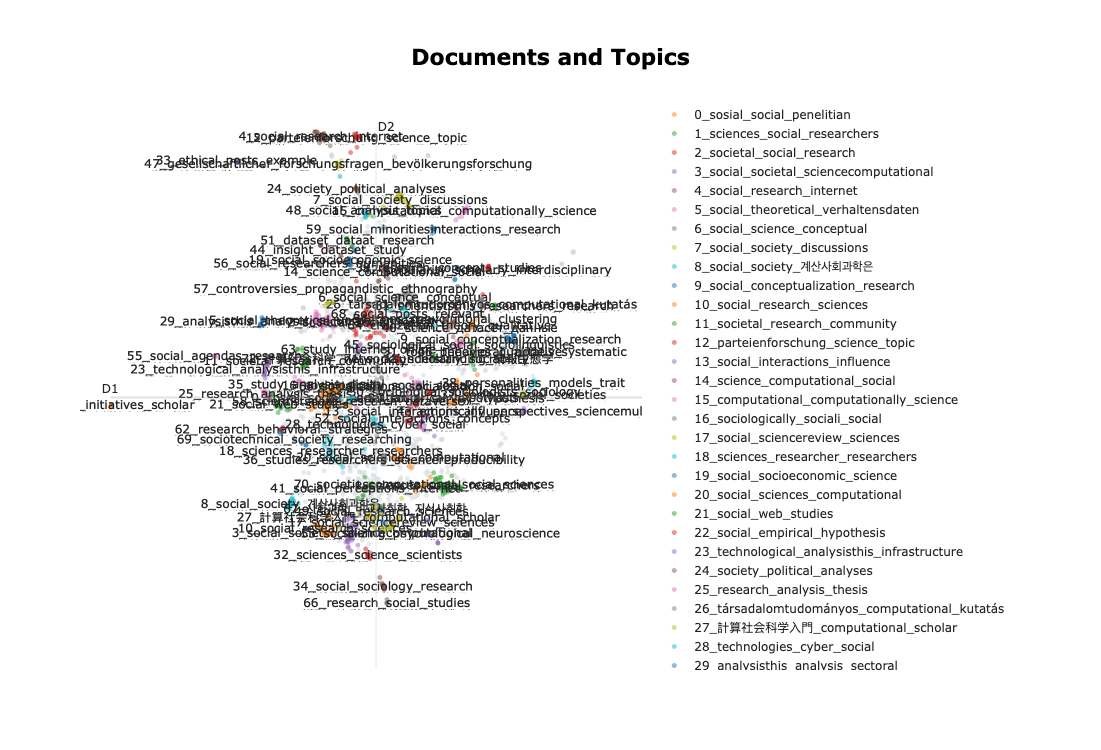

In [21]:
topic_model.visualize_documents(docs)

In [ ]:
# topic_model.get_topic_info()[:20]
# topic_model.visualize_barchart()
# topic_model.visualize_topics()
# topic_model.visualize_hierarchy()
# topic_model.visualize_heatmap()
# topic_model.visualize_documents(docs)


In [ ]:
# Sauver
topic_model.save(
    path="./bertopic-default",
    serialization="safetensors",
    save_ctfidf=False,  # prend de la place
)
# Charger
# topic_model = BERTopic.load("./bertopic-default")

## Trucs plus avancés
- topic par classe
- évolution des topics dans le temps
- réduction des topics, renommer
- etc.

## Réduire les topics

In [ ]:
topic_model.reduce_topics(
    docs=docs, nr_topics=10 + 1
)  # Add one to account for the noise

# Retrieve the updated topics and probabilities
topics_reduced, probabilities_reduced = topic_model.topics_, topic_model.probabilities_

In [ ]:
topic_model.set_topic_labels({
    0: "mon machin",
    1: "conference"
})
# topic_model.get_topic_info()

## À garder en tête

**Choix embeddings**
- fenetre de contexte
- adapté à la langue
- les précalculer pour pas avoir à relancer le calcul à chaque fois… ([ici](https://css-polytechnique.github.io/css-ipp-materials/pages/bertopic-tutorial.html#save-your-instance-locally))

**reproductibilité**
- set seed ([ici](https://css-polytechnique.github.io/css-ipp-materials/pages/bertopic-tutorial.html#save-your-instance-locally))
- sauvegarder son instance bertopic ([ici](https://css-polytechnique.github.io/css-ipp-materials/pages/bertopic-tutorial.html#save-your-instance-locally))

**Évaluer**
- mais surtout éval qualitative ([ici](https://css-polytechnique.github.io/css-ipp-materials/pages/bertopic-tutorial.html#sec-evaluate-your-topic-model))

**Itérer**
- tester des trucs